/tmp/ipykernel_4447/4053881255.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2020-01-01')['Close']
[*********************100%***********************]  3 of 3 completed


Volatility:
 Ticker
HDFCBANK.NS    0.016209
RELIANCE.NS    0.017705
TCS.NS         0.015152
dtype: float64

Correlation Matrix:
 Ticker       HDFCBANK.NS  RELIANCE.NS    TCS.NS
Ticker                                         
HDFCBANK.NS     1.000000     0.436847  0.298383
RELIANCE.NS     0.436847     1.000000  0.366076
TCS.NS          0.298383     0.366076  1.000000

Portfolio Volatility: 0.012469746100557176

95% Daily VaR: -0.0179 (-1.79%)
99% Daily VaR: -0.0318 (-3.18%)


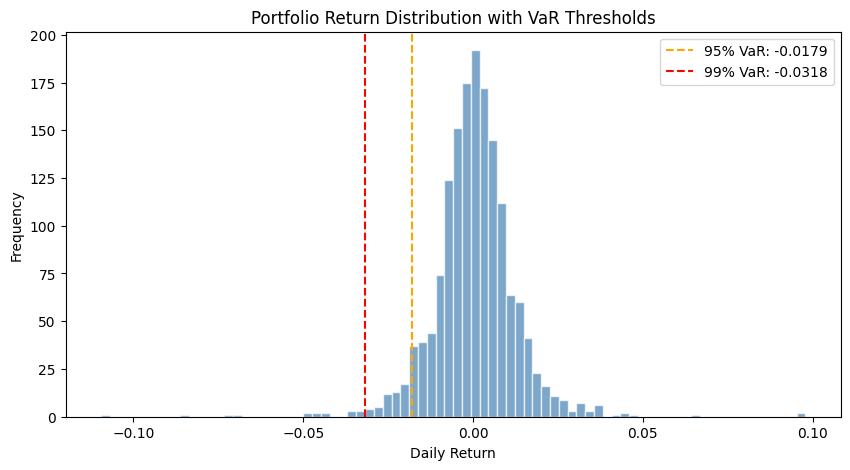


Annualised Portfolio Volatility: 0.1980 (19.80%)

Annualised Individual Volatility:
Ticker
HDFCBANK.NS    0.257313
RELIANCE.NS    0.281051
TCS.NS         0.240523
dtype: float64


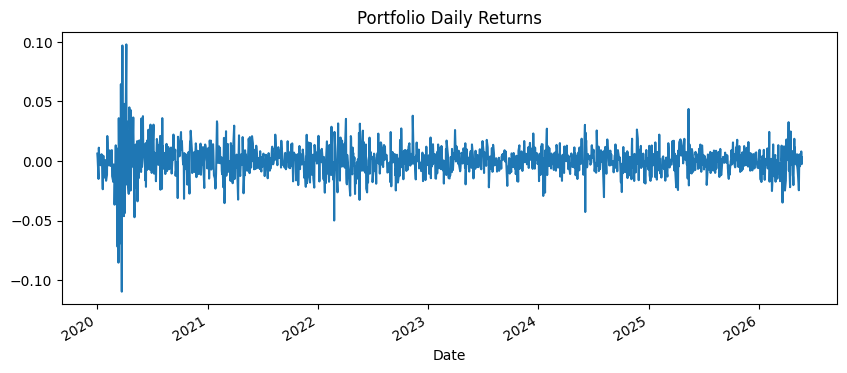

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']

data = yf.download(stocks, start='2020-01-01')['Close']

returns = data.pct_change().dropna()

volatility = returns.std()
print("Volatility:\n", volatility)

correlation = returns.corr()
print("\nCorrelation Matrix:\n", correlation)

weights = np.array([1/3, 1/3, 1/3])

portfolio_returns = returns.dot(weights)
portfolio_volatility = portfolio_returns.std()

print("\nPortfolio Volatility:", portfolio_volatility)

# Annualised volatility (used in banks)
annual_volatility = volatility * np.sqrt(252)
portfolio_annual_volatility = portfolio_volatility * np.sqrt(252)

# VaR calculation
var_95 = np.percentile(portfolio_returns, 5)
var_99 = np.percentile(portfolio_returns, 1)
print(f"\n95% Daily VaR: {var_95:.4f} ({var_95*100:.2f}%)")
print(f"99% Daily VaR: {var_99:.4f} ({var_99*100:.2f}%)")

# Histogram with VaR lines
plt.figure(figsize=(10,5))
plt.hist(portfolio_returns, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(var_95, color='orange', linestyle='--', label=f'95% VaR: {var_95:.4f}')
plt.axvline(var_99, color='red', linestyle='--', label=f'99% VaR: {var_99:.4f}')
plt.title("Portfolio Return Distribution with VaR Thresholds")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Print annualised metrics
print(f"\nAnnualised Portfolio Volatility: {portfolio_annual_volatility:.4f} ({portfolio_annual_volatility*100:.2f}%)")

print("\nAnnualised Individual Volatility:")
print(annual_volatility)


portfolio_returns.plot(figsize=(10,4))
plt.title("Portfolio Daily Returns")
plt.show()

